In [8]:
import pandas as pd
import numpy as np

# Configuration pour la reproductibilité
np.random.seed(42)
n_dossiers = 1000

# 1. Génération des variables de base
data = {
    'ID_Membre': range(1001, 1001 + n_dossiers),
    'Age': np.random.randint(21, 65, n_dossiers),
    'Secteur_Activite': np.random.choice(['Agriculture', 'Commerce', 'Transport', 'Services'], n_dossiers),
    'Anciennete_Coop_Mois': np.random.randint(6, 120, n_dossiers),
    'Revenu_Mensuel_Moyen': np.random.randint(150000, 1500000, n_dossiers), # Francs CFA par ex.
    'Montant_Pret': np.random.randint(500000, 5000000, n_dossiers),
    'Duree_Pret_Mois': np.random.choice([6, 12, 18, 24], n_dossiers),
    'Epargne_Disponible': np.random.randint(50000, 1000000, n_dossiers),
}

df = pd.DataFrame(data)

# 2. Création de variables calculées (Ingénierie financière)
df['Ratio_Endettement'] = (df['Montant_Pret'] / df['Duree_Pret_Mois']) / df['Revenu_Mensuel_Moyen']
df['Couverture_Epargne'] = df['Epargne_Disponible'] / df['Montant_Pret']

# 3. Simulation de la Probabilité de Défaut (PD)
# On crée un score de risque arbitraire pour générer la colonne "Defaut"
# Plus le ratio d'endettement est haut et l'ancienneté basse, plus le risque monte
score_risque = (df['Ratio_Endettement'] * 5) - (df['Anciennete_Coop_Mois'] / 100) + np.random.normal(0, 0.5, n_dossiers)

# Si le score dépasse un seuil, le client est en défaut (1), sinon (0)
df['Statut_Defaut'] = (score_risque > score_risque.quantile(0.85)).astype(int)

# Sauvegarde
df.to_csv('dossiers_prets_coop.csv', index=False)
print("✅ Fichier 'dossiers_prets_coop.csv' généré avec succès !")
print(df.head())

✅ Fichier 'dossiers_prets_coop.csv' généré avec succès !
   ID_Membre  Age Secteur_Activite  Anciennete_Coop_Mois  \
0       1001   59        Transport                     8   
1       1002   49        Transport                    25   
2       1003   35        Transport                    51   
3       1004   63         Commerce                    20   
4       1005   28         Commerce                    30   

   Revenu_Mensuel_Moyen  Montant_Pret  Duree_Pret_Mois  Epargne_Disponible  \
0               1228532       1656083               12              589317   
1               1436916       2474324               18              510829   
2                779085       4398190                6              784803   
3               1062735       3888445               12              238069   
4                571486       3242974                6              414315   

   Ratio_Endettement  Couverture_Epargne  Statut_Defaut  
0           0.112335            0.355850              0

In [9]:
import pandas as pd

# Chargement du fichier généré à l'étape 1
df = pd.read_csv('dossiers_prets_coop.csv')

# 1. Taux de défaut global
taux_defaut_global = df['Statut_Defaut'].mean() * 100

# 2. Analyse par secteur d'activité
# On regarde le taux de défaut et le montant moyen prêté par secteur
analyse_secteur = df.groupby('Secteur_Activite').agg({
    'Statut_Defaut': 'mean',
    'Montant_Pret': 'mean',
    'Ratio_Endettement': 'mean'
}).rename(columns={'Statut_Defaut': 'Taux_Defaut_Secteur'})

analyse_secteur['Taux_Defaut_Secteur'] *= 100

# 3. Corrélation : Le lien entre endettement et défaut
correlation_endettement = df['Ratio_Endettement'].corr(df['Statut_Defaut'])

print(f"--- Diagnostic Flash ---")
print(f"Taux de défaut global : {taux_defaut_global:.2f}%")
print(f"\nAnalyse par secteur :\n{analyse_secteur}")
print(f"\nCorrélation Endettement / Défaut : {correlation_endettement:.4f}")

--- Diagnostic Flash ---
Taux de défaut global : 15.00%

Analyse par secteur :
                  Taux_Defaut_Secteur  Montant_Pret  Ratio_Endettement
Secteur_Activite                                                      
Agriculture                 16.793893  2.605045e+06           0.397808
Commerce                    11.788618  2.642994e+06           0.352305
Services                    16.956522  2.734569e+06           0.392584
Transport                   14.503817  2.673964e+06           0.373853

Corrélation Endettement / Défaut : 0.7161


C:\Users\betos\AppData\Local\Temp\ipykernel_18676\3701046105.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=analyse_secteur.index, y='Taux_Defaut_Secteur', data=analyse_secteur, palette='viridis')
C:\Users\betos\AppData\Local\Temp\ipykernel_18676\3701046105.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Statut_Defaut', y='Ratio_Endettement', data=df, palette='Set2')


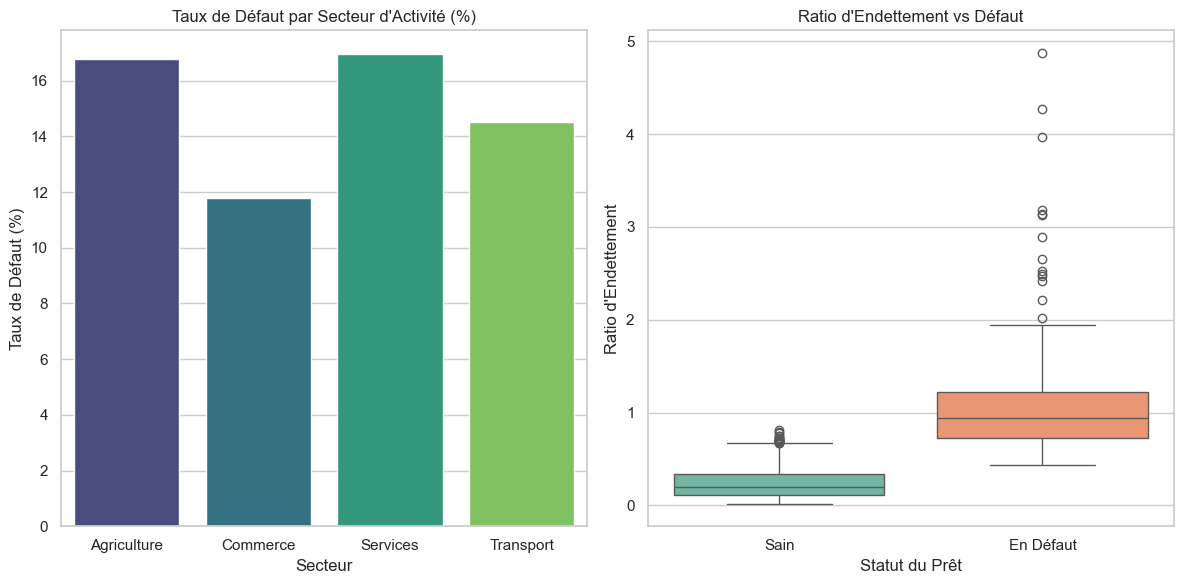

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 1. Graphique à barres : Taux de défaut par secteur
plt.subplot(1, 2, 1)
sns.barplot(x=analyse_secteur.index, y='Taux_Defaut_Secteur', data=analyse_secteur, palette='viridis')
plt.title('Taux de Défaut par Secteur d\'Activité (%)')
plt.ylabel('Taux de Défaut (%)')
plt.xlabel('Secteur')

# 2. Boxplot : Distribution du Ratio d'Endettement selon le statut de défaut
plt.subplot(1, 2, 2)
sns.boxplot(x='Statut_Defaut', y='Ratio_Endettement', data=df, palette='Set2')
plt.title('Ratio d\'Endettement vs Défaut')
plt.xticks([0, 1], ['Sain', 'En Défaut'])
plt.ylabel('Ratio d\'Endettement')
plt.xlabel('Statut du Prêt')

plt.tight_layout()
plt.show()

In [11]:
# Ajout de nouvelles variables (Feature Engineering)
# 1. Ratio de solvabilité immédiate : Épargne / Revenu
df['Ratio_Solvabilite'] = df['Epargne_Disponible'] / df['Revenu_Mensuel_Moyen']

# 2. Score d'engagement : (Ancienneté / Durée du prêt) 
# Plus il est élevé, plus le client est un "fidèle" de la coopérative
df['Indice_Fidelite'] = df['Anciennete_Coop_Mois'] / df['Duree_Pret_Mois']

# 3. Traitement des variables catégorielles (Secteur) en format numérique (One-Hot Encoding)
df = pd.get_dummies(df, columns=['Secteur_Activite'], prefix='Secteur')

print("Nouvelles colonnes créées :")
print(df[['Indice_Fidelite', 'Ratio_Solvabilite']].head())

Nouvelles colonnes créées :
   Indice_Fidelite  Ratio_Solvabilite
0         0.666667           0.479692
1         1.388889           0.355504
2         8.500000           1.007339
3         1.666667           0.224015
4         5.000000           0.724978


In [12]:
%pip install scikit-learn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Sélection des variables explicatives (X) et de la cible (y)
features = ['Age', 'Revenu_Mensuel_Moyen', 'Montant_Pret', 'Duree_Pret_Mois', 
            'Ratio_Endettement', 'Ratio_Solvabilite', 'Indice_Fidelite']
# On ajoute les colonnes générées par le One-Hot Encoding
features += [col for col in df.columns if 'Secteur_' in col]

X = df[features]
y = df['Statut_Defaut']

# 2. Séparation : 80% pour l'entraînement, 20% pour le test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Normalisation (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Données normalisées et prêtes pour le modèle !")

Note: you may need to restart the kernel to use updated packages.
Données normalisées et prêtes pour le modèle !


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# 1. Initialisation et entraînement du modèle
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# 2. Prédictions sur le jeu de test
y_pred = model.predict(X_test_scaled)

# 3. Évaluation de la performance
print("Performance du Modèle :")
print(f"Précision globale : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nRapport de classification détaillé :")
print(classification_report(y_test, y_pred))

Performance du Modèle :
Précision globale : 94.50%

Rapport de classification détaillé :
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       174
           1       0.83      0.73      0.78        26

    accuracy                           0.94       200
   macro avg       0.89      0.85      0.87       200
weighted avg       0.94      0.94      0.94       200



In [14]:
# Extraction des coefficients
coefs = pd.DataFrame({'Variable': features, 'Poids': model.coef_[0]})
coefs = coefs.sort_values(by='Poids', ascending=False)

print("--- Facteurs d'influence sur le Risque de Défaut ---")
print(coefs)

--- Facteurs d'influence sur le Risque de Défaut ---
                Variable     Poids
4      Ratio_Endettement  4.395754
2           Montant_Pret  0.782032
0                    Age  0.309732
5      Ratio_Solvabilite  0.182479
9       Secteur_Services  0.120761
7    Secteur_Agriculture  0.081557
8       Secteur_Commerce -0.060314
10     Secteur_Transport -0.141802
6        Indice_Fidelite -0.729522
1   Revenu_Mensuel_Moyen -0.747365
3        Duree_Pret_Mois -1.229670


In [15]:
# Exemple d'un nouveau profil très risqué
nouveau_client = [[45, 200000, 4000000, 12, 0.9, 0.05, 0.1, 0, 1, 0, 0]] # Exemple fictif
nouveau_client_scaled = scaler.transform(nouveau_client)
prediction = model.predict_proba(nouveau_client_scaled)

print(f"Probabilité de défaut pour ce profil : {prediction[0][1]*100:.2f}%")

Probabilité de défaut pour ce profil : 97.45%


c:\Users\betos\Documents\Excel exo\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [16]:
import pandas as pd
import numpy as np

# Création de 5 profils aberrants
anomalies = pd.DataFrame({
    'ID_Membre': [9991, 9992, 9993, 9994, 9995],
    'Age': [30, 45, 22, 50, 35],
    'Secteur_Activite': ['Commerce', 'Agriculture', 'Services', 'Transport', 'Services'],
    'Anciennete_Coop_Mois': [1, 2, 60, 3, 1], # Très faible ancienneté
    'Revenu_Mensuel_Moyen': [2000000, 100000, 50000, 3000000, 100000],
    'Montant_Pret': [100000, 5000000, 1000000, 5000000, 2000000],
    'Duree_Pret_Mois': [6, 24, 18, 12, 12],
    'Epargne_Disponible': [0, 1000, 500, 0, 0], # Épargne inexistante
    'Ratio_Endettement': [0.05, 2.08, 1.11, 1.38, 1.66] # Très haut
})

# Le modèle doit identifier ces profils comme hautement risqués
# On les ajoute à notre dataframe existant pour test
df_test = pd.concat([df, anomalies], ignore_index=True)

C:\Users\betos\AppData\Local\Temp\ipykernel_18676\3584960044.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=analyse_secteur.index, y='Taux_Defaut_Secteur', data=analyse_secteur, ax=axes[1], palette='magma')


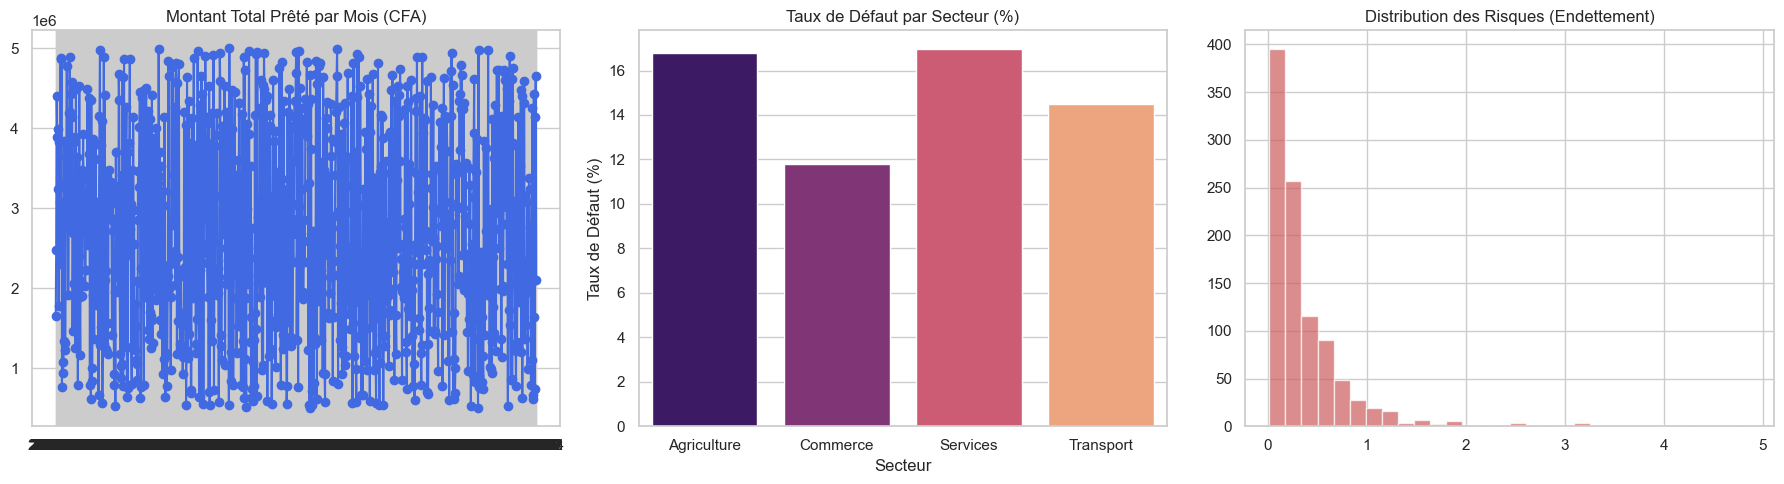

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Supposons que 'df' contient nos données historiques + anomalies
# 1. Évolution du volume des prêts par mois (Simulation)
# on crée une colonne mois/année réaliste pour l’agrégation
dates = pd.date_range(start='2020-01-01', periods=len(df), freq='ME')
df['Mois_Annee'] = dates.strftime('%Y-%m')
evolution = df.groupby('Mois_Annee').agg({
    'Montant_Pret': 'sum',
    'ID_Membre': 'count'
}).rename(columns={'ID_Membre': 'Nombre_Prets'})

# 2. Visualisation 3-en-1
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphique A : Volume des Prêts
axes[0].plot(evolution.index, evolution['Montant_Pret'], marker='o', color='royalblue')
axes[0].set_title('Montant Total Prêté par Mois (CFA)')

# Graphique B : Risque par Secteur
sns.barplot(x=analyse_secteur.index, y='Taux_Defaut_Secteur', data=analyse_secteur, ax=axes[1], palette='magma')
axes[1].set_title('Taux de Défaut par Secteur (%)')
axes[1].set_xlabel('Secteur')
axes[1].set_ylabel('Taux de Défaut (%)')

# Graphique C : Histogramme des Ratios d'Endettement (Détection d'anomalies)
axes[2].hist(df['Ratio_Endettement'], bins=30, color='indianred', alpha=0.7)
axes[2].set_title('Distribution des Risques (Endettement)')

plt.tight_layout()
plt.show()

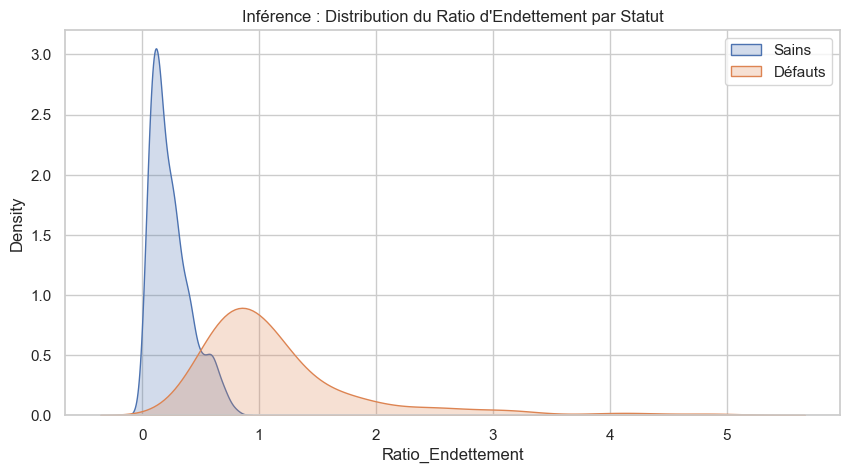

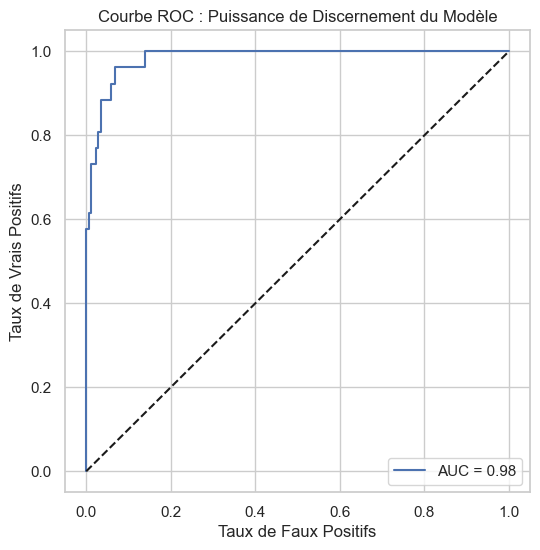

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Comparaison des distributions (Inférence)
plt.figure(figsize=(10, 5))
sns.kdeplot(df[df['Statut_Defaut']==0]['Ratio_Endettement'], label='Sains', fill=True)
sns.kdeplot(df[df['Statut_Defaut']==1]['Ratio_Endettement'], label='Défauts', fill=True)
plt.title('Inférence : Distribution du Ratio d\'Endettement par Statut')
plt.legend()
plt.show()

# 2. Courbe ROC (Performance prédictive)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Courbe ROC : Puissance de Discernement du Modèle')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.legend()
plt.show()

In [21]:
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

def generer_rapport_dg(df, model, X_test_scaled, y_test):
    # 1. Statistiques descriptives globales
    taux_defaut = df['Statut_Defaut'].mean() * 100
    pret_moyen = df['Montant_Pret'].mean()
    
    # 2. Performances du modèle
    y_pred = model.predict(X_test_scaled)
    auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])
    accuracy = accuracy_score(y_test, y_pred)
    
    # 3. Impression du rapport
    print("="*40)
    print("RAPPORT STRATÉGIQUE - ANALYSE RISQUE CRÉDIT")
    print("="*40)
    print(f"Portefeuille total : {len(df)} membres")
    print(f"Taux de sinistralité actuel : {taux_defaut:.2f}%")
    print(f"Montant moyen par prêt : {pret_moyen:,.0f} FCFA")
    print("-"*40)
    print(f"Fiabilité du modèle (Précision) : {accuracy*100:.2f}%")
    print(f"Pouvoir de discrimination (AUC) : {auc:.2f}")
    print("-"*40)
    
    # Affichage des coefficients les plus impactants
    coefs = pd.DataFrame({'Variable': features, 'Impact': model.coef_[0]})
    print("Facteurs clés de risque :")
    print(coefs.sort_values(by='Impact', ascending=False).head(3))
    print("="*40)

# Appel de la fonction
generer_rapport_dg(df, model, X_test_scaled, y_test)

RAPPORT STRATÉGIQUE - ANALYSE RISQUE CRÉDIT
Portefeuille total : 1000 membres
Taux de sinistralité actuel : 15.00%
Montant moyen par prêt : 2,662,228 FCFA
----------------------------------------
Fiabilité du modèle (Précision) : 94.50%
Pouvoir de discrimination (AUC) : 0.98
----------------------------------------
Facteurs clés de risque :
            Variable    Impact
4  Ratio_Endettement  4.395754
2       Montant_Pret  0.782032
0                Age  0.309732
